In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert

from synaptus import (
    MultilayerOmegaKMigration,
    load_mat_dataset,
)

In [2]:
# Load dataset
mat_dataset = load_mat_dataset("PlaneScan3D_PlexiAluFBH.mat")

In [3]:
# Create multilayer omega-k migration object
mulok = MultilayerOmegaKMigration(
    raw_data=mat_dataset.raw_data,
    fs=mat_dataset.fs,
    f_low=mat_dataset.f_low,
    f_high=mat_dataset.f_high,
    x_step=mat_dataset.x_step,  # type:ignore
    y_step=mat_dataset.y_step,  # type:ignore
    t_delay=mat_dataset.t_delay,
    wave_velocities=mat_dataset.wave_vel,
    layer_thicknesses=mat_dataset.layer_thick,
)

In [4]:
# Perform migration (focusing)
images, z_vecs = mulok.mulok_migrate()

In [5]:
# Create C-scans by time and depth gating
t_ind_plexi = (mulok.time_vec >= 88e-6) & (mulok.time_vec <= 106e-6)  # Time gating, 1. layer
t_ind_alu = (mulok.time_vec >= 110e-6) & (mulok.time_vec <= 122.5e-6)  # Time gating, 2. layer

cscan_raw_plexi = np.abs(hilbert(mulok.raw_data[t_ind_plexi, :, :], axis=0)).max(axis=0)
cscan_raw_alu = np.abs(hilbert(mulok.raw_data[t_ind_alu, :, :], axis=0)).max(axis=0)

z_ind_plexi = (z_vecs[1] >= 0.068) & (z_vecs[1] <= 0.092)  # Depth gating, plexiglas layer
z_ind_alu = (z_vecs[2] >= 0.1) & (z_vecs[2] <= 0.14)  # Depth gating, aluminium layer

cscan_im_plexi = images[1][z_ind_plexi, :, :].max(axis=0)
cscan_im_alu = images[2][z_ind_alu, :, :].max(axis=0)


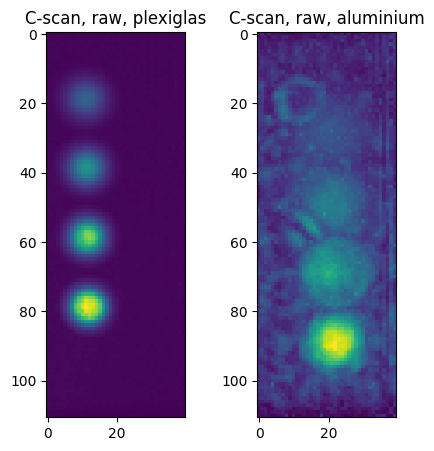

In [6]:
# Plot C-scan for raw data, for both layers
fig, ax = plt.subplots(1, 2, figsize=(5, 5))
ax[0].imshow(cscan_raw_plexi)
ax[1].imshow(cscan_raw_alu)
ax[0].set_title("C-scan, raw, plexiglas")
ax[1].set_title("C-scan, raw, aluminium")
plt.show()


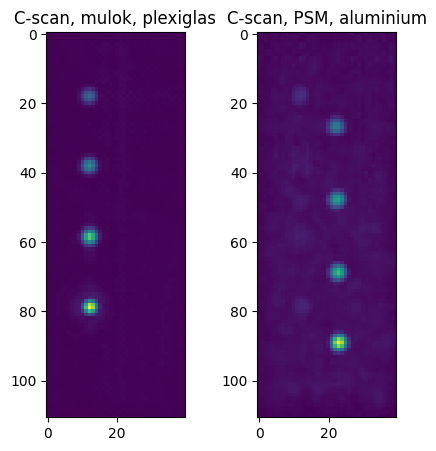

In [7]:
# Plot C-scan for raw data, for both layers
fig, ax = plt.subplots(1, 2, figsize=(5, 5))
ax[0].imshow(cscan_im_plexi)
ax[1].imshow(cscan_im_alu)
ax[0].set_title("C-scan, mulok, plexiglas")
ax[1].set_title("C-scan, PSM, aluminium")
plt.show()

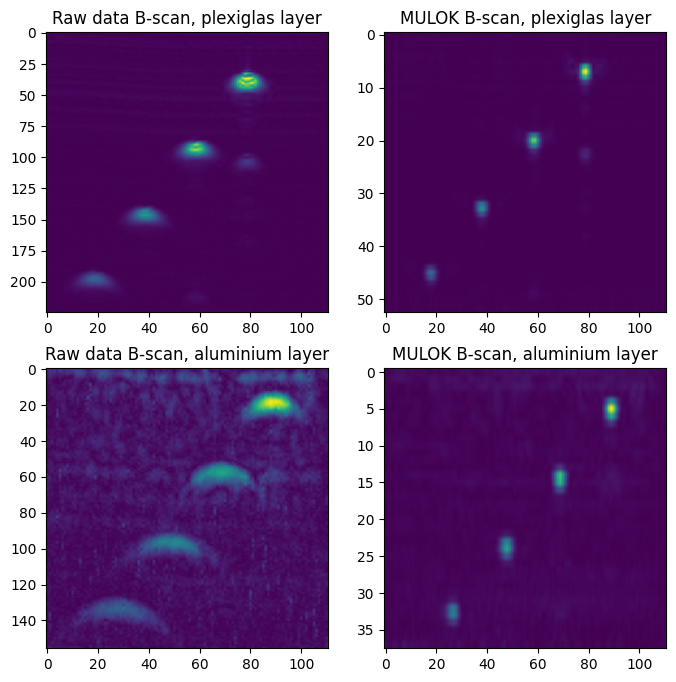

In [8]:
# Plot B-scans for raw data and PSM, for both layers
scatter_index_plexi = 12
scatter_index_alu = 23

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))
ax1.imshow(
    abs(hilbert(np.squeeze(mulok.raw_data[t_ind_plexi, :, scatter_index_plexi]), axis=0)),
    aspect="auto",
)  # type:ignore
ax1.set_title("Raw data B-scan, plexiglas layer")
ax2.imshow(abs(np.squeeze(images[1][z_ind_plexi, :, scatter_index_plexi])), aspect="auto")
ax2.set_title("MULOK B-scan, plexiglas layer")
ax3.imshow(
    abs(hilbert(np.squeeze(mulok.raw_data[t_ind_alu, :, scatter_index_alu]), axis=0)), aspect="auto"
)  # type:ignore
ax3.set_title("Raw data B-scan, aluminium layer")
ax4.imshow(abs(np.squeeze(images[2][z_ind_alu, :, scatter_index_alu])), aspect="auto")
ax4.set_title("MULOK B-scan, aluminium layer")

plt.show()